In [2]:
# Python code: PCA + Hierarchical & KMeans clustering on OWID COVID-19 snapshot
# Requires: pandas, numpy, scikit-learn, scipy, matplotlib, seaborn

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load OWID COVID-19 data (country-level)
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/latest/owid-covid-latest.csv"
df = pd.read_csv(url)
df.head()


,iso_code,continent,location,last_updated_date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2024-08-04,235214.0,0.0,0.000,7998.0,0.0,0.0,...,NaN,37.746,0.50,64.83,0.511,4.112877e+07,NaN,NaN,NaN,NaN
1,OWID_AFR,NaN,Africa,2024-08-04,13145380.0,36.0,5.143,259117.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
2,ALB,Europe,Albania,2024-08-04,335047.0,0.0,0.000,3605.0,0.0,0.0,...,51.2,NaN,2.89,78.57,0.795,2.842318e+06,NaN,NaN,NaN,NaN
3,DZA,Africa,Algeria,2024-08-04,272139.0,18.0,2.571,6881.0,0.0,0.0,...,30.4,83.741,1.90,76.88,0.748,4.490323e+07,NaN,NaN,NaN,NaN
4,ASM,Oceania,American Samoa,2024-08-04,8359.0,0.0,0.000,34.0,0.0,0.0,...,NaN,NaN,NaN,73.74,NaN,4.429500e+04,NaN,NaN,NaN,NaN


In [3]:
for col in df.columns:
    print(col)

iso_code
continent
location
last_updated_date
total_cases
new_cases
new_cases_smoothed
total_deaths
new_deaths
new_deaths_smoothed
total_cases_per_million
new_cases_per_million
new_cases_smoothed_per_million
total_deaths_per_million
new_deaths_per_million
new_deaths_smoothed_per_million
reproduction_rate
icu_patients
icu_patients_per_million
hosp_patients
hosp_patients_per_million
weekly_icu_admissions
weekly_icu_admissions_per_million
weekly_hosp_admissions
weekly_hosp_admissions_per_million
total_tests
new_tests
total_tests_per_thousand
new_tests_per_thousand
new_tests_smoothed
new_tests_smoothed_per_thousand
positive_rate
tests_per_case
tests_units
total_vaccinations
people_vaccinated
people_fully_vaccinated
total_boosters
new_vaccinations
new_vaccinations_smoothed
total_vaccinations_per_hundred
people_vaccinated_per_hundred
people_fully_vaccinated_per_hundred
total_boosters_per_hundred
new_vaccinations_smoothed_per_million
new_people_vaccinated_smoothed
new_people_vaccinated_smooth

Using variables: ['new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million', 'total_cases_per_million', 'total_deaths_per_million', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred']


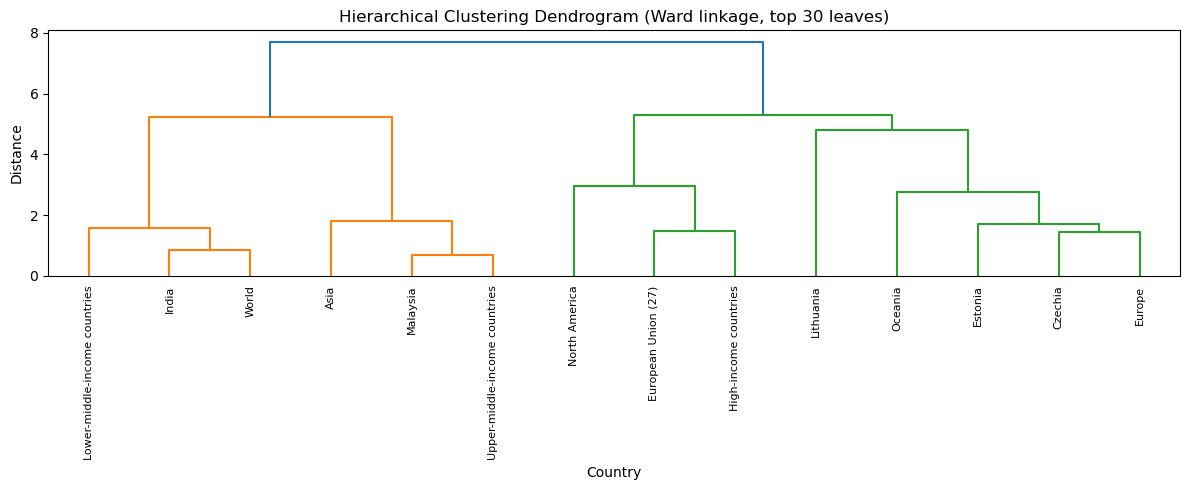

In [6]:
# 2. Select variables (ensure they exist in this latest snapshot)
vars_of_interest = [
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed_per_million",
    "total_cases_per_million",
    "total_deaths_per_million",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "stringency_index"
]

# Check which columns have sufficient non-null values
available_vars = [col for col in vars_of_interest if df[col].notnull().sum() > 0]
print("Using variables:", available_vars)

# Keep countries with non-null values for chosen vars
data = df[["iso_code", "location"] + available_vars].dropna(subset=available_vars).copy()
data.set_index("iso_code", inplace=True)

if len(data) == 0:
    print("No countries have all selected variables. Try with fewer variables or relax missing data requirements.")
else:
    # 3. Standardize features (z-scores)
    scaler = StandardScaler()
    X = scaler.fit_transform(data[available_vars])

    # 4. Hierarchical clustering (Euclidean distance, Ward linkage)
    Z = linkage(X, method="ward", metric="euclidean")

    # Plot dendrogram (truncated for readability)
    plt.figure(figsize=(12, 5))
    dendrogram(Z, labels=data["location"].values, leaf_rotation=90., leaf_font_size=8., truncate_mode="lastp", p=30)
    plt.title("Hierarchical Clustering Dendrogram (Ward linkage, top 30 leaves)")
    plt.xlabel("Country")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


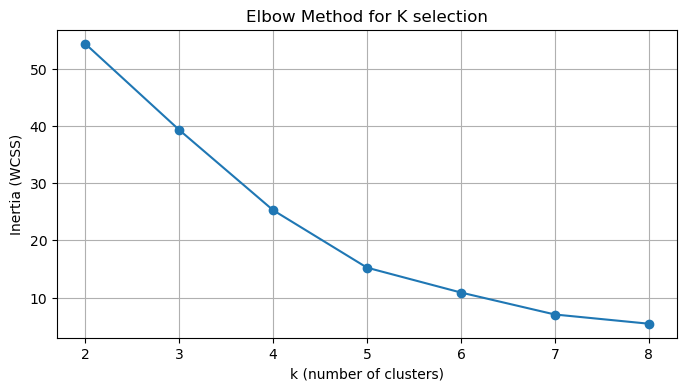

Recommended k by elbow: 6


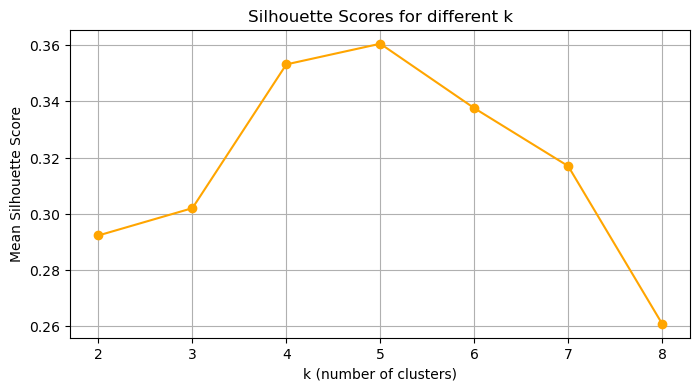

Recommended k by silhouette: 5
Final chosen k: 5


In [19]:
# 5. Use KMeans for k selection (Elbow + Silhouette)
inertia = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Elbow plot
plt.figure(figsize=(8,4))
plt.plot(list(K_range), inertia, '-o')
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for K selection")
plt.grid(True)
plt.show()
best_k_elbow = K_range[int(np.argmin(np.diff(inertia, 2))) + 1]
print(f"Recommended k by elbow: {best_k_elbow}")

# Silhouette plot
plt.figure(figsize=(8,4))
plt.plot(list(K_range), sil_scores, '-o', color='orange')
plt.xlabel("k (number of clusters)")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Scores for different k")
plt.grid(True)
plt.show()

# Choose k (example choose k with highest silhouette)
best_k = K_range[int(np.argmax(sil_scores))]
print(f"Recommended k by silhouette: {best_k}")

#choose best value between best_k and best_k_elbow
best_k = best_k if sil_scores[int(np.argmax(sil_scores))] >= sil_scores[int(np.argmin(np.diff(inertia, 2))) + 1] else best_k_elbow
print(f"Final chosen k: {best_k}")

In [8]:

# 6. Fit final KMeans and Agglomerative (for comparison)
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(X)

data["kmeans_cluster"] = kmeans_final.labels_
data["agglo_cluster"] = agglo.labels_

In [10]:
# 7. Cluster profile table (mean of original variables per cluster)
profile_kmeans = data.groupby("kmeans_cluster")[available_vars].mean()
profile_agglo = data.groupby("agglo_cluster")[available_vars].mean()

print("\nKMeans Cluster Profile (means of original variables):")
display(profile_kmeans.round(3))

print("\nAgglomerative Cluster Profile (means of original variables):")
display(profile_agglo.round(3))


KMeans Cluster Profile (means of original variables):


,new_cases_smoothed_per_million,new_deaths_smoothed_per_million,total_cases_per_million,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
kmeans_cluster,,,,,,
0,5.208,0.024,392339.012,2459.363,66.695,64.848
1,0.300,0.005,52434.480,542.358,69.867,63.977
2,4.014,0.095,323738.303,2677.602,77.120,70.960
3,40.926,0.000,486117.470,3482.525,71.210,68.400
4,1.775,0.001,101944.509,806.897,81.513,77.773



Agglomerative Cluster Profile (means of original variables):


,new_cases_smoothed_per_million,new_deaths_smoothed_per_million,total_cases_per_million,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
agglo_cluster,,,,,,
0,4.014,0.095,323738.303,2677.602,77.120,70.960
1,1.775,0.001,101944.509,806.897,81.513,77.773
2,5.208,0.024,392339.012,2459.363,66.695,64.848
3,0.300,0.005,52434.480,542.358,69.867,63.977
4,40.926,0.000,486117.470,3482.525,71.210,68.400


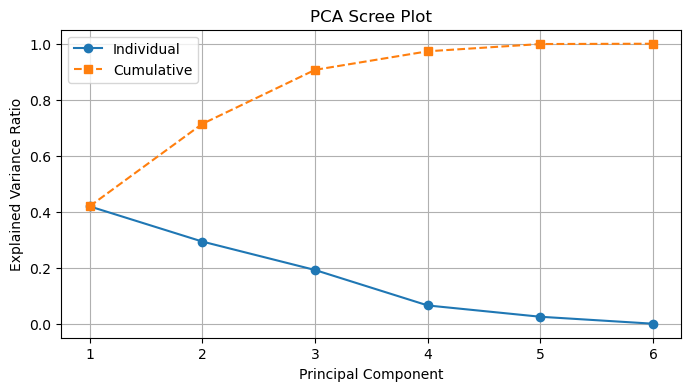

PC1: 0.420 (Cumulative: 0.420)
PC2: 0.294 (Cumulative: 0.714)
PC3: 0.193 (Cumulative: 0.907)
PC4: 0.066 (Cumulative: 0.973)
PC5: 0.026 (Cumulative: 0.999)
PC6: 0.001 (Cumulative: 1.000)

PCA Loadings (first 3 PCs shown):


,PC1,PC2,PC3
new_cases_smoothed_per_million,0.411,0.245,-0.469
new_deaths_smoothed_per_million,0.121,0.184,0.853
total_cases_per_million,0.564,0.207,-0.013
total_deaths_per_million,0.525,0.319,0.127
people_vaccinated_per_hundred,-0.373,0.598,0.060
people_fully_vaccinated_per_hundred,-0.289,0.636,-0.181


In [14]:
# 8. PCA: scree plot, explained variance, and loadings
pca = PCA(n_components=min(X.shape[1], X.shape[0]))
pca.fit(X)
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
# Scree plot
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(explained_var)+1), explained_var, 'o-', label="Individual")
plt.plot(np.arange(1, len(explained_var)+1), cum_var, 's--', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(np.arange(1, len(explained_var)+1))
plt.legend()
plt.grid(True)
plt.show()

# Print explained variance summary
for i, (ev, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: {ev:.3f} (Cumulative: {cv:.3f})")

# PCA loadings (components x original features)
loadings = pd.DataFrame(pca.components_.T,
                        index=available_vars,
                        columns=[f"PC{i}" for i in range(1, len(available_vars)+1)])
print("\nPCA Loadings (first 3 PCs shown):")
display(loadings.iloc[:, :3].round(3))


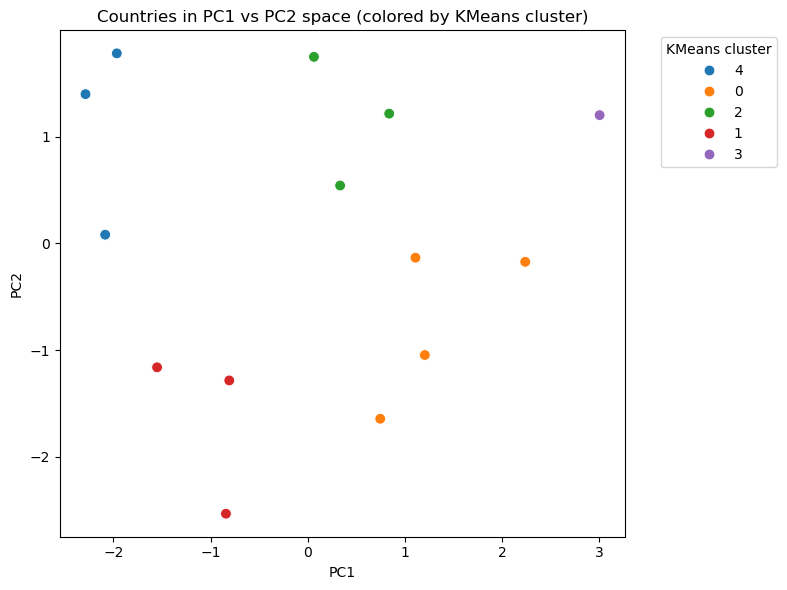

In [15]:
# 9. Simple scatter of PC1 vs PC2 colored by KMeans cluster
pc_scores = pca.transform(X)[:, :2]
plt.figure(figsize=(8,6))
sns.scatterplot(x=pc_scores[:,0], y=pc_scores[:,1], hue=data["kmeans_cluster"].astype(str), palette="tab10", s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Countries in PC1 vs PC2 space (colored by KMeans cluster)")
plt.legend(title="KMeans cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
# 10. Export cluster assignment and profile to CSV (optional)
data_reset = data.reset_index()
data_reset.to_csv("owid_covid_clusters_profile.csv", index=False)

print("\nDone. 'owid_covid_clusters_profile.csv' written with cluster labels and variables.")


Done. 'owid_covid_clusters_profile.csv' written with cluster labels and variables.


iso_code
continent
location
last_updated_date
total_cases
new_cases
new_cases_smoothed
total_deaths
new_deaths
new_deaths_smoothed
total_cases_per_million
new_cases_per_million
new_cases_smoothed_per_million
total_deaths_per_million
new_deaths_per_million
new_deaths_smoothed_per_million
reproduction_rate
icu_patients
icu_patients_per_million
hosp_patients
hosp_patients_per_million
weekly_icu_admissions
weekly_icu_admissions_per_million
weekly_hosp_admissions
weekly_hosp_admissions_per_million
total_tests
new_tests
total_tests_per_thousand
new_tests_per_thousand
new_tests_smoothed
new_tests_smoothed_per_thousand
positive_rate
tests_per_case
tests_units
total_vaccinations
people_vaccinated
people_fully_vaccinated
total_boosters
new_vaccinations
new_vaccinations_smoothed
total_vaccinations_per_hundred
people_vaccinated_per_hundred
people_fully_vaccinated_per_hundred
total_boosters_per_hundred
new_vaccinations_smoothed_per_million
new_people_vaccinated_smoothed
new_people_vaccinated_smooth

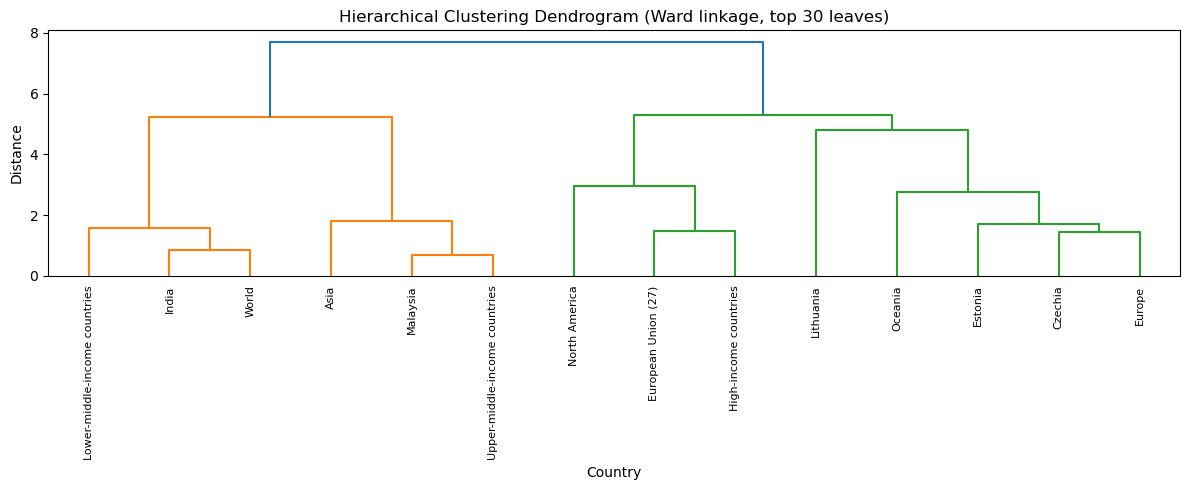

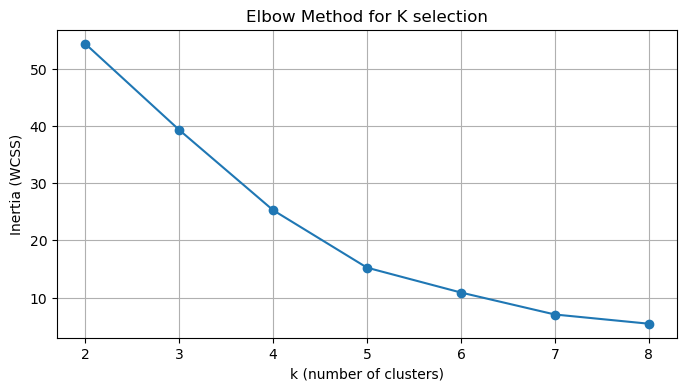

Recommended k by elbow: 6


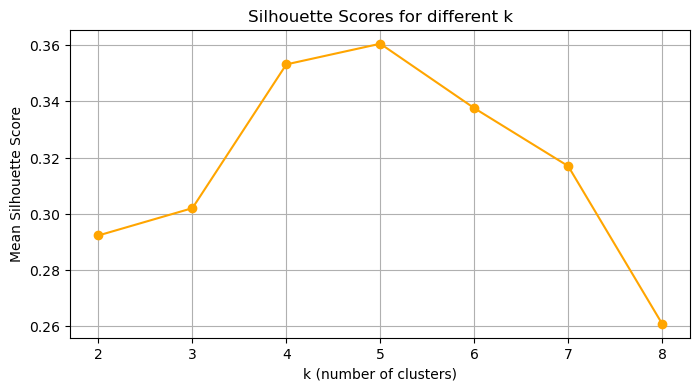

Recommended k by silhouette: 5
Final chosen k: 5

KMeans Cluster Profile (means of original variables):


,new_cases_smoothed_per_million,new_deaths_smoothed_per_million,total_cases_per_million,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
kmeans_cluster,,,,,,
0,5.208,0.024,392339.012,2459.363,66.695,64.848
1,0.300,0.005,52434.480,542.358,69.867,63.977
2,4.014,0.095,323738.303,2677.602,77.120,70.960
3,40.926,0.000,486117.470,3482.525,71.210,68.400
4,1.775,0.001,101944.509,806.897,81.513,77.773



Agglomerative Cluster Profile (means of original variables):


,new_cases_smoothed_per_million,new_deaths_smoothed_per_million,total_cases_per_million,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
agglo_cluster,,,,,,
0,4.014,0.095,323738.303,2677.602,77.120,70.960
1,1.775,0.001,101944.509,806.897,81.513,77.773
2,5.208,0.024,392339.012,2459.363,66.695,64.848
3,0.300,0.005,52434.480,542.358,69.867,63.977
4,40.926,0.000,486117.470,3482.525,71.210,68.400


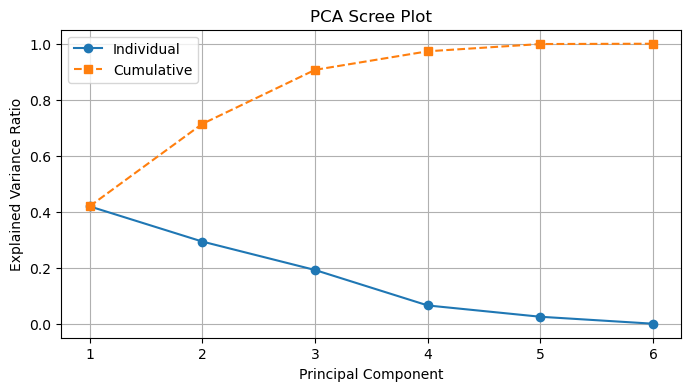

PC1: 0.420 (Cumulative: 0.420)
PC2: 0.294 (Cumulative: 0.714)
PC3: 0.193 (Cumulative: 0.907)
PC4: 0.066 (Cumulative: 0.973)
PC5: 0.026 (Cumulative: 0.999)
PC6: 0.001 (Cumulative: 1.000)

PCA Loadings (first 3 PCs shown):


,PC1,PC2,PC3
new_cases_smoothed_per_million,0.411,0.245,-0.469
new_deaths_smoothed_per_million,0.121,0.184,0.853
total_cases_per_million,0.564,0.207,-0.013
total_deaths_per_million,0.525,0.319,0.127
people_vaccinated_per_hundred,-0.373,0.598,0.060
people_fully_vaccinated_per_hundred,-0.289,0.636,-0.181


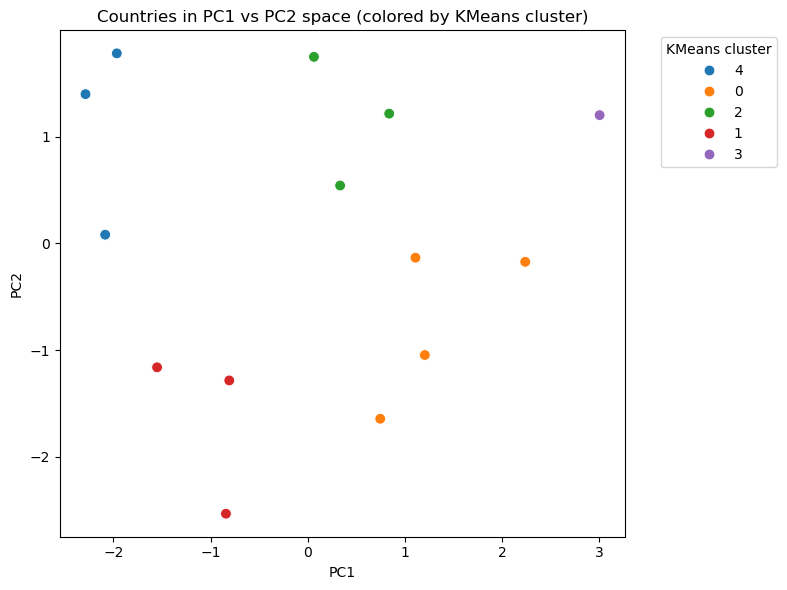


Done. 'owid_covid_clusters_profile.csv' written with cluster labels and variables.


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

# Python code: PCA + Hierarchical & KMeans clustering on OWID COVID-19 snapshot
# Requires: pandas, numpy, scikit-learn, scipy, matplotlib, seaborn

import matplotlib.pyplot as plt

# 1. Load OWID COVID-19 data (country-level)
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/latest/owid-covid-latest.csv"
df = pd.read_csv(url)
df.head()

# Print all column names
for col in df.columns:
    print(col)

# 2. Select variables (ensure they exist in this latest snapshot)
vars_of_interest = [
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed_per_million",
    "total_cases_per_million",
    "total_deaths_per_million",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "stringency_index"
]

# Check which columns have sufficient non-null values
available_vars = [col for col in vars_of_interest if df[col].notnull().sum() > 0]
print("Using variables:", available_vars)

# Keep countries with non-null values for chosen vars
data = df[["iso_code", "location"] + available_vars].dropna(subset=available_vars).copy()
data.set_index("iso_code", inplace=True)

if len(data) == 0:
    print("No countries have all selected variables. Try with fewer variables or relax missing data requirements.")
else:
    # 3. Standardize features (z-scores)
    scaler = StandardScaler()
    X = scaler.fit_transform(data[available_vars])

    # 4. Hierarchical clustering (Euclidean distance, Ward linkage)
    Z = linkage(X, method="ward", metric="euclidean")

    # Plot dendrogram (truncated for readability)
    plt.figure(figsize=(12, 5))
    dendrogram(Z, labels=data["location"].values, leaf_rotation=90., leaf_font_size=8., truncate_mode="lastp", p=30)
    plt.title("Hierarchical Clustering Dendrogram (Ward linkage, top 30 leaves)")
    plt.xlabel("Country")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # 5. Use KMeans for k selection (Elbow + Silhouette)
    inertia = []
    sil_scores = []
    K_range = range(2, 9)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertia.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(X, labels))

    # Elbow plot
    plt.figure(figsize=(8,4))
    plt.plot(list(K_range), inertia, '-o')
    plt.xlabel("k (number of clusters)")
    plt.ylabel("Inertia (WCSS)")
    plt.title("Elbow Method for K selection")
    plt.grid(True)
    plt.show()
    best_k_elbow = K_range[int(np.argmin(np.diff(inertia, 2))) + 1]
    print(f"Recommended k by elbow: {best_k_elbow}")

    # Silhouette plot
    plt.figure(figsize=(8,4))
    plt.plot(list(K_range), sil_scores, '-o', color='orange')
    plt.xlabel("k (number of clusters)")
    plt.ylabel("Mean Silhouette Score")
    plt.title("Silhouette Scores for different k")
    plt.grid(True)
    plt.show()

    # Choose k (example choose k with highest silhouette)
    best_k = K_range[int(np.argmax(sil_scores))]
    print(f"Recommended k by silhouette: {best_k}")

    #choose best value between best_k and best_k_elbow
    best_k = best_k if sil_scores[int(np.argmax(sil_scores))] >= sil_scores[int(np.argmin(np.diff(inertia, 2))) + 1] else best_k_elbow
    print(f"Final chosen k: {best_k}")

    # 6. Fit final KMeans and Agglomerative (for comparison)
    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
    agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(X)

    data["kmeans_cluster"] = kmeans_final.labels_
    data["agglo_cluster"] = agglo.labels_

    # 7. Cluster profile table (mean of original variables per cluster)
    profile_kmeans = data.groupby("kmeans_cluster")[available_vars].mean()
    profile_agglo = data.groupby("agglo_cluster")[available_vars].mean()

    print("\nKMeans Cluster Profile (means of original variables):")
    display(profile_kmeans.round(3))

    print("\nAgglomerative Cluster Profile (means of original variables):")
    display(profile_agglo.round(3))

    # 8. PCA: scree plot, explained variance, and loadings
    pca = PCA(n_components=min(X.shape[1], X.shape[0]))
    pca.fit(X)
    explained_var = pca.explained_variance_ratio_
    cum_var = np.cumsum(explained_var)
    # Scree plot
    plt.figure(figsize=(8,4))
    plt.plot(np.arange(1, len(explained_var)+1), explained_var, 'o-', label="Individual")
    plt.plot(np.arange(1, len(explained_var)+1), cum_var, 's--', label="Cumulative")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title("PCA Scree Plot")
    plt.xticks(np.arange(1, len(explained_var)+1))
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print explained variance summary
    for i, (ev, cv) in enumerate(zip(explained_var, cum_var), start=1):
        print(f"PC{i}: {ev:.3f} (Cumulative: {cv:.3f})")

    # PCA loadings (components x original features)
    loadings = pd.DataFrame(pca.components_.T,
                            index=available_vars,
                            columns=[f"PC{i}" for i in range(1, len(available_vars)+1)])
    print("\nPCA Loadings (first 3 PCs shown):")
    display(loadings.iloc[:, :3].round(3))

    # 9. Simple scatter of PC1 vs PC2 colored by KMeans cluster
    pc_scores = pca.transform(X)[:, :2]
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=pc_scores[:,0], y=pc_scores[:,1], hue=data["kmeans_cluster"].astype(str), palette="tab10", s=60)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Countries in PC1 vs PC2 space (colored by KMeans cluster)")
    plt.legend(title="KMeans cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 10. Export cluster assignment and profile to CSV (optional)
    data_reset = data.reset_index()
    data_reset.to_csv("owid_covid_clusters_profile.csv", index=False)

    print("\nDone. 'owid_covid_clusters_profile.csv' written with cluster labels and variables.")